# **Ejercicio 1. Análisis Exploratorio de Datos**

# *Planteamiento*

Considere la serie de tiempo asociada con las acciones de Bitcoin (ver https://github.com/lihkir/Data/blob/main/btc_15m_data_2018_to_2025.csv importe directamente con el link y pd.read_csv). Realice un Análisis Exploratorio de Datos (EDA) considerando cada una de las metodología abordadas durante el curso. Es crucial que en todos los ejercicios de la presente evaluación, cada figura descriptiva, tabla o resumen de resultados, cuente con su respectiva interpretación

Utilice el conjunto de datos asociados con el precio de Bitcoin. Considere para las predicciones con modelos de series de tiempo, la columna Price

Identifique si existen datos faltantes y realice su imputación usando alguna de las técnicas básicas estudiadas durante el curso.

Realice un grafico de velas utilizando la librería Plotly para la serie de tiempo (columna Price). Realice también un histograma con Plotly para representar el volumen tradeado diariamente (Volume)

Realice graficos de subseries considerando agrupación por semana, mes y año. Utilice graficos de series de tiempo y boxplots para analizar estas subseries.

Estudie estacionariedad de la serie de tiempo usando la ACF estudiada durante el curso, así como también los respectivos test estadísticos tales como Ljung-Box y Dickey Fuller. Aplique además las transformaciones necesarias para convertir la serie de tiempo en estacionaria.

Mediante agregación por grupos analice el comportamiento de la media y desviación estándar, agrupando por semanas, días, meses. Además, para estas agrupaciones, calcule estadísticos móviles. Dibuje la distribución de frecuencias para diferentes lags como se realizó en las notas del curso.

Aplique las medias móviles $\widehat{M}_t^{(2)}$, $\widehat{M}_t^{(2)}(t,t+1)$, $\widehat{M}_t^{(4)}(t,t+1)$, $\widehat{M}_t^{(3)}$, y $\widehat{M}_t^{(3)}(t-1,t+1)$  a la serie del precio de cierre de BTC-USD. Posteriormente, úselas para remover tendencia y aplique la prueba de Dickey-Fuller y Ljung-Box para verificar si se logró estacionariedad.


- Realice descomposición de la serie temporal del precio de cierre de BTC-USD usando **medias móviles** y además usando la librería **statsmodels.tsa**. Verifique al final independencia de los residuos mediante la prueba de **Ljung-Box**.

(II) Repita el análisis anterior para las series de tiempo de: retorno acumulado diario y volatilidad, para diferentes ventanas. Para esto tenga en cuenta las siguientes definiciones e implemente manualmente las funciones que definen cada serie de tiempo  

- **Retorno acumulado diario** $\{A_t\}_{t=1}^{T}$ donde  

$$
A_t = \sum_{j=1}^{t} R_j, \quad \text{con} \quad R_t = \frac{P_t - P_{t-1}}{P_{t-1}},
$$  

donde $P_t, t=1,2,\dots,T$ es la columna *Price* en el dataset de Bitcoin y $T$ es el tiempo final.

- **La volatilidad** $\{\sigma_t\}_{t=1}^{T}$ es la desviación estándar de los retornos diarios  

$$
\sigma = \text{std}(R_1, R_2, \dots, R_{\omega}) \quad \text{donde} \quad \omega = 7, 14, 21, 28,
\tag{2}
$$  

siendo $\omega$ el número de retornos diarios considerados para calcular la desviación estándar  

$$
\text{std}(R_1, R_2, \dots, R_{\omega}) = \sqrt{\frac{1}{\omega - 1} \sum_{t=1}^{\omega} (R_t - \mu)}, \quad \mu = \frac{1}{\omega} \sum_{t=1}^{\omega} R_t,
\tag{3}
$$  

obtenida por ventanas móviles de longitud $\omega$, donde $\omega$ está dado en días, y esta desviación es calculada sobre la serie de retornos diarios. Para cada ventana $\omega$ repita el ítem (I).


# *Solución*

## 1.1 Cargue y preparación de datos

In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
 
# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')
 
# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)

In [ ]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(4999, 6)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4999 entries, 2010-07-18 to 2024-03-24
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     4999 non-null   float64
 1   Open      4999 non-null   float64
 2   High      4999 non-null   float64
 3   Low       4999 non-null   float64
 4   Vol.      4993 non-null   float64
 5   Change %  4999 non-null   float64
dtypes: float64(6)
memory usage: 273.4 KB
None
Price       0
Open        0
High        0
Low         0
Vol.        6
Change %    0
dtype: int64


In [ ]:
print(df.head())

            Price  Open  High  Low    Vol.  Change %
Date                                                
2010-07-18    0.1   0.0   0.1  0.1    80.0       0.0
2010-07-19    0.1   0.1   0.1  0.1   570.0       0.0
2010-07-20    0.1   0.1   0.1  0.1   260.0       0.0
2010-07-21    0.1   0.1   0.1  0.1   580.0       0.0
2010-07-22    0.1   0.1   0.1  0.1  2160.0       0.0


In [ ]:
print(df[df.isnull().any(axis=1)])

            Price  Open  High   Low  Vol.  Change %
Date                                               
2011-06-20   17.5  17.5  17.5  17.5   NaN       0.0
2011-06-21   17.5  17.5  17.5  17.5   NaN       0.0
2011-06-22   17.5  17.5  17.5  17.5   NaN       0.0
2011-06-23   17.5  17.5  17.5  17.5   NaN       0.0
2011-06-24   17.5  17.5  17.5  17.5   NaN       0.0
2011-06-25   17.5  17.5  17.5  17.5   NaN       0.0


In [ ]:
# Contar valores nulos en cada columna
valores_faltantes = df.isnull().sum()

# Filtrar solo las columnas que tienen valores nulos
valores_faltantes = valores_faltantes[valores_faltantes > 0]

# Mostrar resultado
print("Valores faltantes por columna:")
print(valores_faltantes)

Valores faltantes por columna:
Vol.    6
dtype: int64


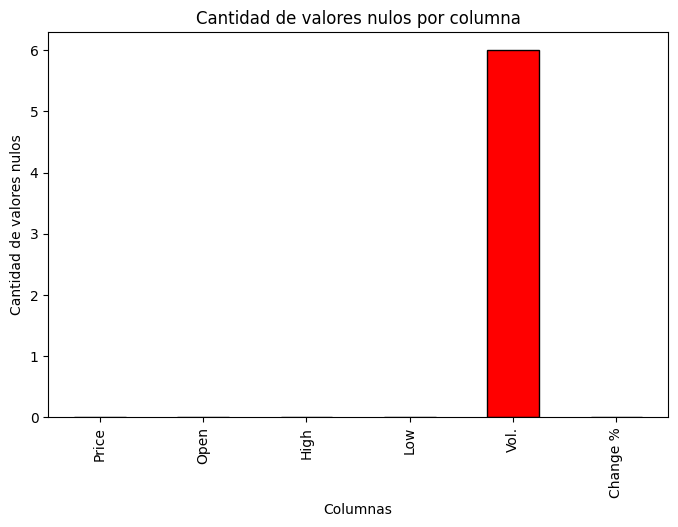

In [ ]:
# Gráfica de Barras (Conteo de Valores Faltantes)

df.isnull().sum().plot(kind='bar', color='red', figsize=(8, 5), edgecolor='black')

# Título y etiquetas
plt.title("Cantidad de valores nulos por columna")
plt.xlabel("Columnas")
plt.ylabel("Cantidad de valores nulos")
plt.show()

In [ ]:
# Contar valores faltantes por columna
missing_values = df.isnull().sum()

# Mostrar solo columnas con valores faltantes
missing_values = missing_values[missing_values > 0]

# Imprimir el resultado
print(missing_values)

Vol.    6
dtype: int64


In [ ]:
# Imputación combinada: Imputación por propagación hacia adelante y hacia atras (ffill + bfill).
df.fillna(method='bfill', inplace=True)  # Usa el siguiente valor disponible
df.fillna(method='ffill', inplace=True)  # Usa el valor anterior si sigue habiendo nulos

In [ ]:
# Verificar si los valores faltantes fueron imputados
missing_values_after = df['Price'].isna().sum()
print(f"Número de valores faltantes después de la imputación: {missing_values_after}")

Número de valores faltantes después de la imputación: 0


## 1.2 Visualización y análisis descriptivo

In [ ]:
# Graficar la serie de precios
import plotly.express as px  
graph_price = px.line(df, x=df.index, y='Price', title='Serie Temporal del Precio de Bitcoin')
graph_price.show()

In [ ]:
# Gráfico de velas con Plotly
import plotly.graph_objects as go
fig_candlestick = go.Figure(data=[
    go.Candlestick(x=df.index,
                   open=df['Open'], high=df['High'],
                   low=df['Low'], close=df['Price'])
])
fig_candlestick.update_layout(title='Gráfico de Velas de Bitcoin')
fig_candlestick.show()

In [ ]:
# Histograma del Vol.n tradeado
g = px.histogram(df, x='Vol.', nbins=50, title='Histograma del Vol.n Tradeado')
g.show()

In [ ]:
# Conviersión de todas las columnas de tipo Period a str antes de graficar:

df['Year'] = df.index.to_period('Y').astype(str)
df['Month'] = df.index.to_period('M').astype(str)  # Convertir 'Month' a string
df['Week'] = df.index.to_period('W').astype(str)   # Convertir 'Week' a string

# Gráficos de subseries por semana, mes y año.
fig_weekly = px.box(df, x='Week', y='Price', title='Distribución del Precio por Semana')
fig_weekly.show()

fig_monthly = px.box(df, x='Month', y='Price', title='Distribución del Precio por Mes')
fig_monthly.show()

fig_yearly = px.box(df, x='Year', y='Price', title='Distribución del Precio por Año')
fig_yearly.show()

## 1.3 Análisis de estacionariedad

<Figure size 1000x500 with 0 Axes>

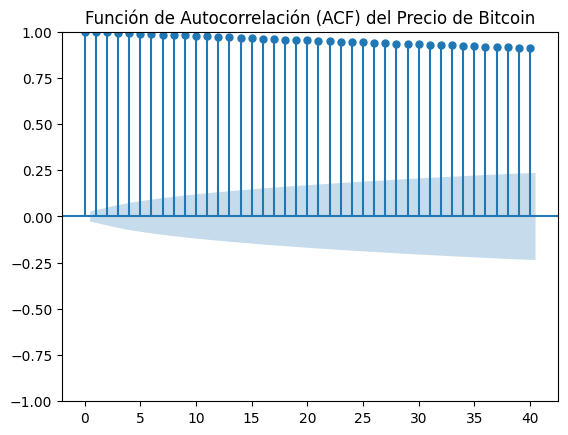

In [ ]:
# Análisis de estacionariedad con ACF
plt.figure(figsize=(10,5))
sm.graphics.tsa.plot_acf(df['Price'].dropna(), lags=40)
plt.title('Función de Autocorrelación (ACF) del Precio de Bitcoin')
plt.show()

In [ ]:
# Análisis de estacionariedad con Dickey Fuller
from statsmodels.tsa.stattools import adfuller
result = adfuller(df['Price'])
print(f"Dickey-Fuller p-value: {result[1]}")

Dickey-Fuller p-value: 0.9426372256091571


In [ ]:
# Prueba de independencia de residuos con Ljung-Box
ljung_box_results = q_stat(acf(df['Price'], nlags=20, fft=True)[1:], len(df))
print(f"Ljung-Box p-values: {ljung_box_results[1]}")

Ljung-Box p-values: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


                                     SARIMAX Results                                      
Dep. Variable:                              Price   No. Observations:                 4999
Model:             SARIMAX(2, 1, 1)x(1, 0, 1, 48)   Log Likelihood              -39386.839
Date:                            Sun, 16 Mar 2025   AIC                          78785.678
Time:                                    10:26:19   BIC                          78824.718
Sample:                                07-18-2010   HQIC                         78799.368
                                     - 03-24-2024                                         
Covariance Type:                           approx                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9279      0.019     47.621      0.000       0.890       0.966
ar.L2          0.0597      0.015   

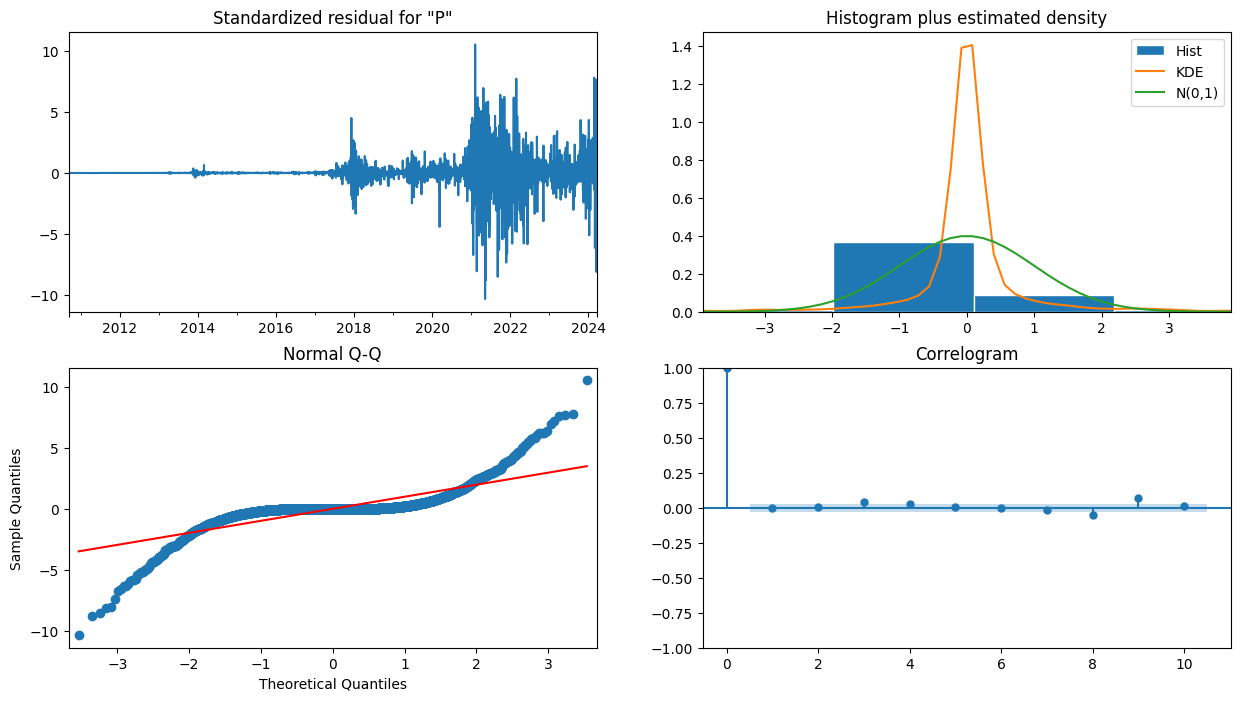

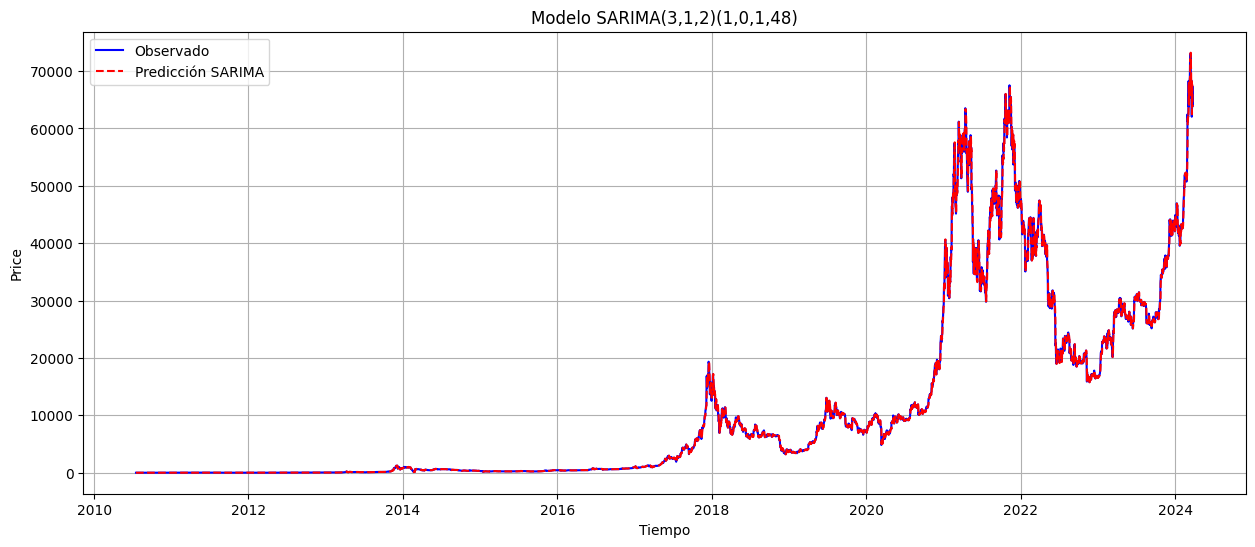

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
 
# Ajustamos el modelo SARIMA(3,1,2)(1,0,1,48)
order = (2, 1, 1)  # ARIMA(p,d,q)
seasonal_order = (1, 0, 1, 48)  # Estacional (P,D,Q,s)
 
# Entrenamos el modelo
model = SARIMAX(df['Price'], order=order, seasonal_order=seasonal_order,
                enforce_stationarity=False, enforce_invertibility=False)
results = model.fit(low_memory=True)
 
# Resumen del modelo
print(results.summary())
 
# Diagnóstico de residuos
results.plot_diagnostics(figsize=(15, 8))
plt.show()
 
# Predicción
df['forecast'] = results.predict(start=0, end=len(df)-1, dynamic=False)
 
# Visualización
plt.figure(figsize=(15,6))
plt.plot(df['Price'], label='Observado', color='blue')
plt.plot(df['forecast'], label='Predicción SARIMA', color='red', linestyle='dashed')
plt.legend()
plt.title('Modelo SARIMA(3,1,2)(1,0,1,48)')
plt.xlabel('Tiempo')
plt.ylabel('Price')
plt.grid()
plt.show()
 
 

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox
import numpy as np
price_series = df["Price"]
log_price = np.log(price_series + 1)  # Evita log(0)
log_price_diff = log_price.diff().dropna()
ljung_box_log = acorr_ljungbox(log_price_diff, lags=[1], return_df=True)
print(ljung_box_log)
 

   lb_stat  lb_pvalue
1  0.41889   0.517492


## 1.4 Análisis de agregaciones y estadísticas móviles

In [ ]:
# Agregación por grupos

import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
 
# Asegurarse de que la columna 'Date' está en formato datetime
df['Date'] = df.index
df['Date'] = pd.to_datetime(df['Date'])
df['Date'] = pd.to_datetime(df['Date'])
 
# Crear columnas adicionales para semana, mes, día y año
df['Week'] = df['Date'].dt.isocalendar().week
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Day'] = df['Date'].dt.day
 
# Agrupar por semana, mes, día y año
weekly_data = df.groupby('Week').agg({'Price': 'mean', 'Vol.': 'sum'}).reset_index()
monthly_data = df.groupby('Month').agg({'Price': 'mean', 'Vol.': 'sum'}).reset_index()
daily_data = df.groupby('Day').agg({'Price': 'mean', 'Vol.': 'sum'}).reset_index()
yearly_data = df.groupby('Year').agg({'Price': 'mean', 'Vol.': 'sum'}).reset_index()
 
# Gráfico de serie de tiempo para cada subserie
fig_weekly = go.Figure()
fig_weekly.add_trace(go.Scatter(x=weekly_data['Week'], y=weekly_data['Price'], mode='lines', name='Precio Promedio Semanal'))
fig_weekly.update_layout(title="Serie de Tiempo - Precio Promedio Semanal",
                         xaxis_title="Semana", yaxis_title="Precio de Cierre",
                         template="plotly_dark")
fig_monthly = go.Figure()
fig_monthly.add_trace(go.Scatter(x=monthly_data['Month'], y=monthly_data['Price'], mode='lines', name='Precio Promedio Mensual'))
fig_monthly.update_layout(title="Serie de Tiempo - Precio Promedio Mensual",
                          xaxis_title="Mes", yaxis_title="Precio de Cierre",
                          template="plotly_dark")
fig_daily = go.Figure()
fig_daily.add_trace(go.Scatter(x=daily_data['Day'], y=daily_data['Price'], mode='lines', name='Precio Promedio Diario'))
fig_daily.update_layout(title="Serie de Tiempo - Precio Promedio Diario",
                        xaxis_title="Día", yaxis_title="Precio de Cierre",
                        template="plotly_dark")
fig_yearly = go.Figure()
fig_yearly.add_trace(go.Scatter(x=yearly_data['Year'], y=yearly_data['Price'], mode='lines', name='Precio Promedio Anual'))
fig_yearly.update_layout(title="Serie de Tiempo - Precio Promedio Anual",
                         xaxis_title="Año", yaxis_title="Precio de Cierre",
                         template="plotly_dark")
 
# Mostrar los gráficos de series de tiempo
fig_weekly.show()
fig_monthly.show()
fig_daily.show()
fig_yearly.show()
 
# Calcular estadísticas móviles (promedio móvil y desviación estándar)
df['Moving_Avg_7'] = df['Price'].rolling(window=7).mean()
df['Moving_Std_7'] = df['Price'].rolling(window=7).std()
df['Moving_Avg_30'] = df['Price'].rolling(window=30).mean()
df['Moving_Std_30'] = df['Price'].rolling(window=30).std()
 
# Boxplot para analizar las subseries por semana, mes, día y año
fig_weekly_box = px.box(df, x='Week', y='Price', title="Boxplot del Precio de Cierre por Semana")
fig_monthly_box = px.box(df, x='Month', y='Price', title="Boxplot del Precio de Cierre por Mes")
fig_daily_box = px.box(df, x='Day', y='Price', title="Boxplot del Precio de Cierre por Día")
fig_yearly_box = px.box(df, x='Year', y='Price', title="Boxplot del Precio de Cierre por Año")
 
# Mostrar los boxplots
fig_weekly_box.show()
fig_monthly_box.show()
fig_daily_box.show()
fig_yearly_box.show()
 
# Calcular distribución de frecuencias para diferentes lags
df['Lag_1'] = df['Price'].shift(1)
df['Lag_7'] = df['Price'].shift(7)
df['Lag_30'] = df['Price'].shift(30)
 
# Histograma para visualizar la distribución de frecuencias de los lags
fig_lag_1 = px.histogram(df, x='Lag_1', title='Distribución de Frecuencia - Lag 1')
fig_lag_7 = px.histogram(df, x='Lag_7', title='Distribución de Frecuencia - Lag 7')
fig_lag_30 = px.histogram(df, x='Lag_30', title='Distribución de Frecuencia - Lag 30')
 
# Mostrar histogramas
fig_lag_1.show()
fig_lag_7.show()
fig_lag_30.show()

 

In [ ]:
# Cálculo de estadísticos móviles
df['Rolling_Mean_7'] = df['Price'].rolling(window=7).mean()
df['Rolling_Std_7'] = df['Price'].rolling(window=7).std()

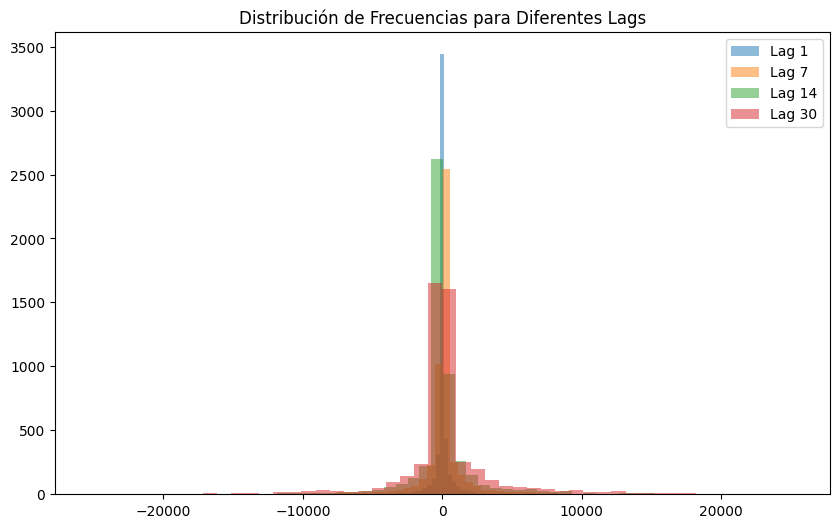

In [ ]:
# Distribución de frecuencias para diferentes lags
lags = [1, 7, 14, 30]
plt.figure(figsize=(10,6))
for lag in lags:
    plt.hist(df['Price'].diff(lag).dropna(), bins=50, alpha=0.5, label=f'Lag {lag}')
plt.legend()
plt.title("Distribución de Frecuencias para Diferentes Lags")
plt.show()

## 1.5 Aplicación de medias móviles

In [ ]:
# Medias móviles
df['SMA_7'] = df['Price'].rolling(window=7).mean()
df['SMA_14'] = df['Price'].rolling(window=14).mean()

In [ ]:
# Graficar medias móviles
fig_ma = px.line(df, x=df.index, y=['Price', 'SMA_7', 'SMA_14'], title='Medias Móviles del Precio de Bitcoin')
fig_ma.show()

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
 
# Calcular medias móviles
df['cM2_t'] = df['Price'].rolling(window=2).mean()
df['cM2_t_t1'] = df['Price'].rolling(window=2).mean().shift(-1)
df['cM3_t'] = df['Price'].rolling(window=3).mean()
df['cM3_t_t1'] = df['Price'].rolling(window=3).mean().shift(-1)
df['cM3_t_t-1'] = df['Price'].rolling(window=3, center=True).mean()
df['cM4_t'] = df['Price'].rolling(window=4).mean()
df['cM4_t_t1'] = df['Price'].rolling(window=4).mean().shift(-1)
 
# Lista de columnas de medias móviles
ma_columns = ['cM2_t', 'cM2_t_t1', 'cM3_t', 'cM3_t_t1', 'cM3_t_t-1', 'cM4_t', 'cM4_t_t1']
 
# Remover tendencia para cada media móvil
for col in ma_columns:
    df[f'detrended_{col}'] = df['Price'] - df[col]
 
# Prueba de Dickey-Fuller para verificar estacionariedad en cada detrended
print("Resultados de la Prueba de Dickey-Fuller:")
for col in ma_columns:
    detrended_col = f'detrended_{col}'
    adf_test = adfuller(df[detrended_col].dropna())
    print(f"\n{detrended_col}:")
    print(f"  Estadístico: {adf_test[0]}")
    print(f"  P-valor: {adf_test[1]}")
 
# Prueba de Ljung-Box para independencia de residuos en cada detrended
print("\nResultados de la Prueba de Ljung-Box:")
for col in ma_columns:
    detrended_col = f'detrended_{col}'
    ljung_box_test = acorr_ljungbox(df[detrended_col].dropna(), lags=[10], return_df=True)
    print(f"\n{detrended_col}:")
    print(ljung_box_test)

Resultados de la Prueba de Dickey-Fuller:

detrended_cM2_t:
  Estadístico: -9.886578088339864
  P-valor: 3.6505273415731896e-17

detrended_cM2_t_t1:
  Estadístico: -9.886578088339824
  P-valor: 3.6505273415740586e-17

detrended_cM3_t:
  Estadístico: -9.515926723298962
  P-valor: 3.157399273322918e-16

detrended_cM3_t_t1:
  Estadístico: -22.671517074530176
  P-valor: 0.0

detrended_cM3_t_t-1:
  Estadístico: -22.671517074530176
  P-valor: 0.0

detrended_cM4_t:
  Estadístico: -9.249080004579433
  P-valor: 1.509310071203713e-15

detrended_cM4_t_t1:
  Estadístico: -10.313327846709523
  P-valor: 3.1437135226531228e-18

Resultados de la Prueba de Ljung-Box:

detrended_cM2_t:
     lb_stat     lb_pvalue
10  72.61667  1.381782e-11

detrended_cM2_t_t1:
     lb_stat     lb_pvalue
10  72.61667  1.381782e-11

detrended_cM3_t:
      lb_stat      lb_pvalue
10  748.84869  2.029879e-154

detrended_cM3_t_t1:
        lb_stat  lb_pvalue
10  1483.553462        0.0

detrended_cM3_t_t-1:
        lb_stat  lb_p

## 1.6 Descomposición de la serie temporal

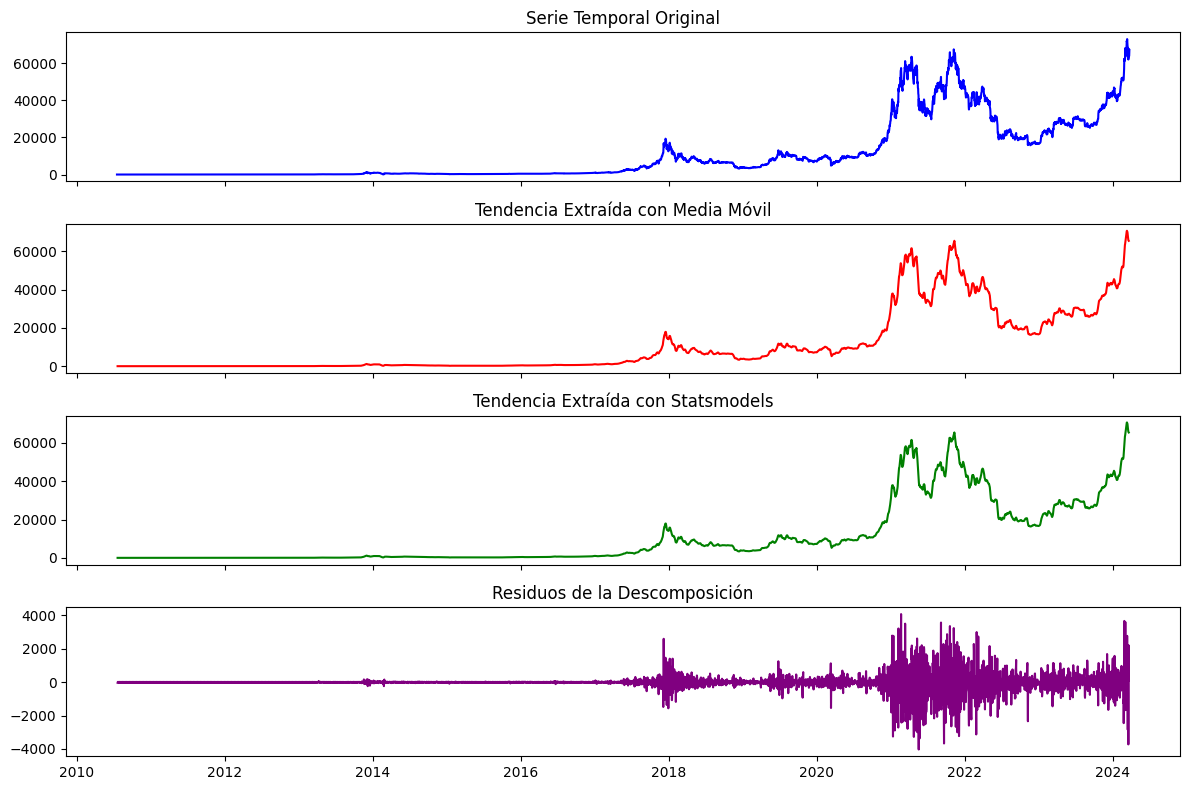


Prueba de Ljung-Box sobre los residuos:
        lb_stat      lb_pvalue
10  1026.374408  3.889671e-214


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox

# -------------------------------------------
# 1. DESCOMPOSICIÓN USANDO MEDIAS MÓVILES
# -------------------------------------------
df['Trend_MA'] = df['Price'].rolling(window=7, center=True).mean()  # Media móvil de 7 días
df['Detrended_MA'] = df['Price'] - df['Trend_MA']  # Eliminando la tendencia

# -------------------------------------------
# 2. DESCOMPOSICIÓN USANDO STATSMODELS
# -------------------------------------------
decomp = seasonal_decompose(df['Price'], model='additive', period=7)  # Periodo de 7 días

# Extraer componentes
df['Trend_SM'] = decomp.trend
df['Seasonal_SM'] = decomp.seasonal
df['Residual_SM'] = decomp.resid

# -------------------------------------------
# 3. VERIFICACIÓN DE INDEPENDENCIA CON LJUNG-BOX
# -------------------------------------------
ljung_box_test = acorr_ljungbox(df['Residual_SM'].dropna(), lags=[10], return_df=True)

# -------------------------------------------
# 4. VISUALIZACIÓN DE LOS RESULTADOS
# -------------------------------------------
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
axes[0].plot(df['Price'], label="Serie Original", color='blue')
axes[0].set_title("Serie Temporal Original")
axes[1].plot(df['Trend_MA'], label="Tendencia (Media Móvil)", color='red')
axes[1].set_title("Tendencia Extraída con Media Móvil")
axes[2].plot(df['Trend_SM'], label="Tendencia (Statsmodels)", color='green')
axes[2].set_title("Tendencia Extraída con Statsmodels")
axes[3].plot(df['Residual_SM'], label="Residuos", color='purple')
axes[3].set_title("Residuos de la Descomposición")
plt.tight_layout()
plt.show()

# -------------------------------------------
# 5. RESULTADOS DE LJUNG-BOX
# -------------------------------------------
print("\nPrueba de Ljung-Box sobre los residuos:")
print(ljung_box_test)


## 1.7 Repetición del análisis para retorno acumulado y volatilidad

In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
 
# =========================================
# 1. Lectura de datos y limpieza
# =========================================

# Cargar datos
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4999 entries, 2024-03-24 to 2010-07-18
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     4999 non-null   float64
 1   Open      4999 non-null   float64
 2   High      4999 non-null   float64
 3   Low       4999 non-null   float64
 4   Vol.      4993 non-null   float64
 5   Change %  4999 non-null   float64
dtypes: float64(6)
memory usage: 273.4 KB


In [ ]:
df["Return"] = df["Price"].pct_change()
df["Return"].iloc[0] = 0  # Reemplazar el primer NaN con 0
 
# Calcular el retorno acumulado diario
df["Cumulative Return"] = df["Return"].cumsum()
 
# Ventanas de tiempo para la volatilidad
windows = [7, 14, 21, 28]
 
# Calcular la volatilidad con ventanas móviles
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()

In [ ]:
df

,Price,Open,High,Low,Vol.,Change %,Return,Cumulative Return,Volatility_7d,Volatility_14d,Volatility_21d,Volatility_28d
Date,,,,,,,,,,,,
2024-03-24,67211.9,64036.5,67587.8,63812.9,65590.0,4.96,0.000000,0.000000,NaN,NaN,NaN,NaN
2024-03-23,64037.8,63785.6,65972.4,63074.9,35110.0,0.40,-0.047225,-0.047225,0.033393,0.033393,0.033393,0.033393
2024-03-22,63785.5,65501.5,66633.3,62328.3,72430.0,-2.62,-0.003940,-0.051165,0.026202,0.026202,0.026202,0.026202
2024-03-21,65503.8,67860.0,68161.7,64616.1,75260.0,-3.46,0.026939,-0.024226,0.030685,0.030685,0.030685,0.030685
2024-03-20,67854.0,62046.8,68029.5,60850.9,133530.0,9.35,0.035879,0.011652,0.032525,0.032525,0.032525,0.032525
...,...,...,...,...,...,...,...,...,...,...,...,...
2010-07-22,0.1,0.1,0.1,0.1,2160.0,0.00,0.000000,-4.322978,0.000000,0.000000,0.000000,0.000000
2010-07-21,0.1,0.1,0.1,0.1,580.0,0.00,0.000000,-4.322978,0.000000,0.000000,0.000000,0.000000
2010-07-20,0.1,0.1,0.1,0.1,260.0,0.00,0.000000,-4.322978,0.000000,0.000000,0.000000,0.000000


In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
 
# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')
 
# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()

In [ ]:
cols = ["Volatility_7d", "Volatility_14d", "Volatility_21d", "Volatility_28d"]
df[cols] = df[cols].fillna(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4999 entries, 2010-07-18 to 2024-03-24
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Price              4999 non-null   float64
 1   Open               4999 non-null   float64
 2   High               4999 non-null   float64
 3   Low                4999 non-null   float64
 4   Vol.               4993 non-null   float64
 5   Change %           4999 non-null   float64
 6   Return             4999 non-null   float64
 7   Cumulative_Return  4999 non-null   float64
 8   Volatility_7d      4999 non-null   float64
 9   Volatility_14d     4999 non-null   float64
 10  Volatility_21d     4999 non-null   float64
 11  Volatility_28d     4999 non-null   float64
dtypes: float64(12)
memory usage: 507.7 KB


In [ ]:
df.isna().sum()

Price                0
Open                 0
High                 0
Low                  0
Vol.                 6
Change %             0
Return               0
Cumulative_Return    0
Volatility_7d        0
Volatility_14d       0
Volatility_21d       0
Volatility_28d       0
dtype: int64

In [ ]:
# Imputación combinada: Imputación por propagación hacia adelante y hacia atras (ffill + bfill).
df.fillna(method='bfill', inplace=True)  # Usa el siguiente valor disponible
df.fillna(method='ffill', inplace=True)  # Usa el valor anterior si sigue habiendo nulos

In [ ]:
df.isna().sum()

Price                0
Open                 0
High                 0
Low                  0
Vol.                 0
Change %             0
Return               0
Cumulative_Return    0
Volatility_7d        0
Volatility_14d       0
Volatility_21d       0
Volatility_28d       0
dtype: int64

In [ ]:
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)

In [ ]:
df

,Price,Open,High,Low,Volume,Change,Return,Cumulative_Return,Volatility_7d,Volatility_14d,Volatility_21d,Volatility_28d
Date,,,,,,,,,,,,
2010-07-18,0.1,0.0,0.1,0.1,80.0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2010-07-19,0.1,0.1,0.1,0.1,570.0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2010-07-20,0.1,0.1,0.1,0.1,260.0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2010-07-21,0.1,0.1,0.1,0.1,580.0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2010-07-22,0.1,0.1,0.1,0.1,2160.0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-03-20,67854.0,62046.8,68029.5,60850.9,133530.0,9.35,0.093537,23.719802,0.060681,0.044544,0.044059,0.043374
2024-03-21,65503.8,67860.0,68161.7,64616.1,75260.0,-3.46,-0.034636,23.685166,0.061287,0.045543,0.044563,0.044045
2024-03-22,63785.5,65501.5,66633.3,62328.3,72430.0,-2.62,-0.026232,23.658934,0.061256,0.045630,0.044883,0.044397
